# **Analysis of Deprivation and Statistical Inference Report**¶

**Week 2 Group Assignment — Index of Multiple Deprivation (IMD)*.** 

This official government measure takes into account various socio-economic health variables such as income. 

Analysis of the relationship between the relevant deprivation scores dating from 2019 and median house prices across London LSOAs from 2022.

*The Index of Multiple Deprivation is "the official measure of relative deprivation in England and is part of a suite of outputs that form the English Indices of Deprivation (IoD)". Source: https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025/english-indices-of-deprivation-2025-statistical-release

According to Oxford Consultants for Social Inclusion (OCSI):

"The IMD ranks can be grouped into ten equal-sized bands called deciles to make comparison easier. 

Decile 1 represents the 10% most deprived LSOAs in England, and decile 10 represents the 10% least deprived. 

The IMD can also be split into quintiles (five bands) – allowing you to focus on specific cut-offs such as the most deprived 20% of areas."

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
import statsmodels.api as sm
import warnings
from matplotlib.ticker import StrMethodFormatter
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

In [84]:
final_df = pd.read_csv('data/final_dataset.csv')
print(f'Dataset loaded: {len(final_df):,} LSOAs')
print(final_df.columns.tolist())

Dataset loaded: 4,757 LSOAs
['Local authority code', 'Local authority name', 'LSOA code', 'LSOA name', 'Median House Price 2022', 'Arson and Criminal Damage', 'Burglary', 'Drug Offences', 'Miscellaneous Crimes Against Society', 'Possession of Weapons', 'Public Order Offences', 'Robbery', 'Theft', 'Vehicle Offences', 'Violence Against The Person', 'Total Crime 2022', 'IMD Score', 'Income Deprivation Rank', 'Employment Deprivation Rank', 'Education Deprivation Rank', 'Health Deprivation Rank', 'Crime Deprivation Rank', 'Housing and Services Deprivation Rank', 'Living Environment Deprivation Rank', 'Total Population 2015', 'Average PTAI 2015', 'PTAL']


## Task 1: Explanatory Data Analysis (Crime & House Prices)

### 1. Univariate Analysis: Descriptive Statistics

Key summary statistics for Median House Price 2022 and IMD score 2019.

In [85]:
# Summary statistics
print('=== MEDIAN HOUSE PRICE 2022 ===')
desc = final_df['Median House Price 2022'].describe()

print(f"count    {int(desc['count']):,}")
print(f"mean     £{desc['mean']:,.0f}")
print(f"std      £{desc['std']:,.0f}")
print(f"min      £{desc['min']:,.0f}")
print(f"25%      £{desc['25%']:,.0f}")
print(f"50%      £{desc['50%']:,.0f}")
print(f"75%      £{desc['75%']:,.0f}")
print(f"max      £{desc['max']:,.0f}")

print('\n=== IMD Score ===')
print(final_df['IMD Score'].describe().apply(lambda x: f'{x:,.1f}'))

price_med = final_df['Median House Price 2022'].median()
IMD_med = final_df['IMD Score'].median()
IMD_q25 = final_df['IMD Score'].quantile(0.25)
IMD_q75 = final_df['IMD Score'].quantile(0.75)
print(f'\nHouse Price Median: £{price_med:,.0f}')
print(f'Median IMD Score: {IMD_med:.0f}, IQR: [{IMD_q25:.0f}-{IMD_q75:.0f}]')

=== MEDIAN HOUSE PRICE 2022 ===
count    4,757
mean     £617,913
std      £396,309
min      £147,500
25%      £420,000
50%      £520,000
75%      £683,000
max      £6,425,000

=== IMD Score ===
count    4,757.0
mean        21.2
std         10.7
min          2.3
25%         12.3
50%         20.1
75%         29.2
max         59.0
Name: IMD Score, dtype: object

House Price Median: £520,000
Median IMD Score: 20, IQR: [12-29]


### 2. Bivariate Analysis: Total Crime vs Median House Price

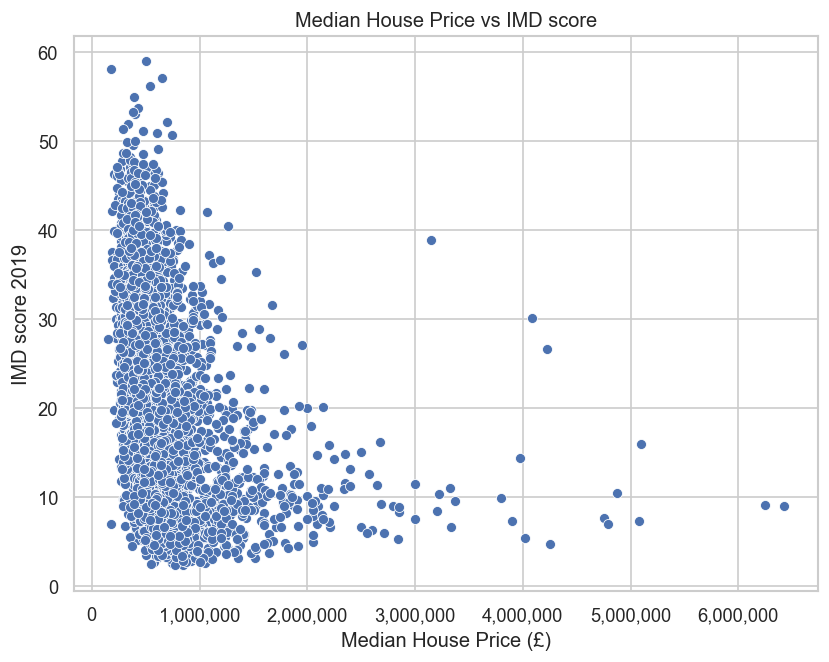

In [86]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=final_df,
    x='Median House Price 2022',
    y='IMD Score'
)

plt.title('Median House Price vs IMD score')
plt.xlabel('Median House Price (£)')
plt.ylabel('IMD score 2019')
plt.grid(True)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.show()

## Task 2: Hypothesis Testing and Statistical Inference¶
We test one hypothesis identified from our EDA:

High IMD score areas have significantly lower median house prices than low IMD score areas

### Hypothesis: One-Tailed Two-Sample Welch's t-Test

**H₀:** μ_high ≥ μ_low (highly deprived areas have equal or higher prices)  
**H₁:** μ_high < μ_low (highly deprived areas have lower prices)  

Groups are defined within each scenario using the 75th (high) and 25th (low) percentile thresholds of Total Crime.

In [87]:
# Define high- and low-deprivation groups using quartiles
q75 = final_df['IMD Score'].quantile(0.75)
q25 = final_df['IMD Score'].quantile(0.25)

high = final_df[final_df['IMD Score'] >= q75]['Median House Price 2022'].dropna()
low = final_df[final_df['IMD Score'] <= q25]['Median House Price 2022'].dropna()

# Welch's t-test
t_stat, p_two = ttest_ind(high, low, equal_var=False)

# One-tailed p-value (H1: High deprivation < Low deprivation)
if t_stat < 0:
    p_one = p_two / 2
else:
    p_one = 1 - p_two / 2

# Mean difference and 95% CI
diff = high.mean() - low.mean()
se = np.sqrt(high.var(ddof=1) / len(high) + low.var(ddof=1) / len(low))
ci_lo = diff - 1.96 * se
ci_hi = diff + 1.96 * se

# Print results
print("=" * 60)
print("H1: One-Tailed Welch's t-Test")
print("=" * 60)

print(f"Number of highly deprived neighbourhoods: {len(high)}")
print(f"Number of low-deprived neighbourhoods:    {len(low)}")

print(f"\nMean House Price (High Deprivation): £{high.mean():,.2f}")
print(f"Mean House Price (Low Deprivation):  £{low.mean():,.2f}")
print(f"Difference (High − Low):             £{diff:,.2f}")

print(f"\nt-statistic: {t_stat:.4f}")
print(f"One-tailed p-value: {p_one:.4e}")

print(f"95% Confidence Interval: [£{ci_lo:,.2f}, £{ci_hi:,.2f}]")

if p_one < 0.05:
    print("\nDecision: Reject H₀")
    print("There is significant evidence that highly deprived neighbourhoods have lower median house prices than low-deprived neighbourhoods.")
else:
    print("\nDecision: Fail to reject H₀")
    print("There is insufficient evidence that highly deprived neighbourhoods have lower median house prices than low-deprived neighbourhoods.")

H1: One-Tailed Welch's t-Test
Number of highly deprived neighbourhoods: 1190
Number of low-deprived neighbourhoods:    1190

Mean House Price (High Deprivation): £464,300.16
Mean House Price (Low Deprivation):  £844,754.91
Difference (High − Low):             £-380,454.75

t-statistic: -21.3474
One-tailed p-value: 1.1283e-88
95% Confidence Interval: [£-415,385.95, £-345,523.54]

Decision: Reject H₀
There is significant evidence that highly deprived neighbourhoods have lower median house prices than low-deprived neighbourhoods.


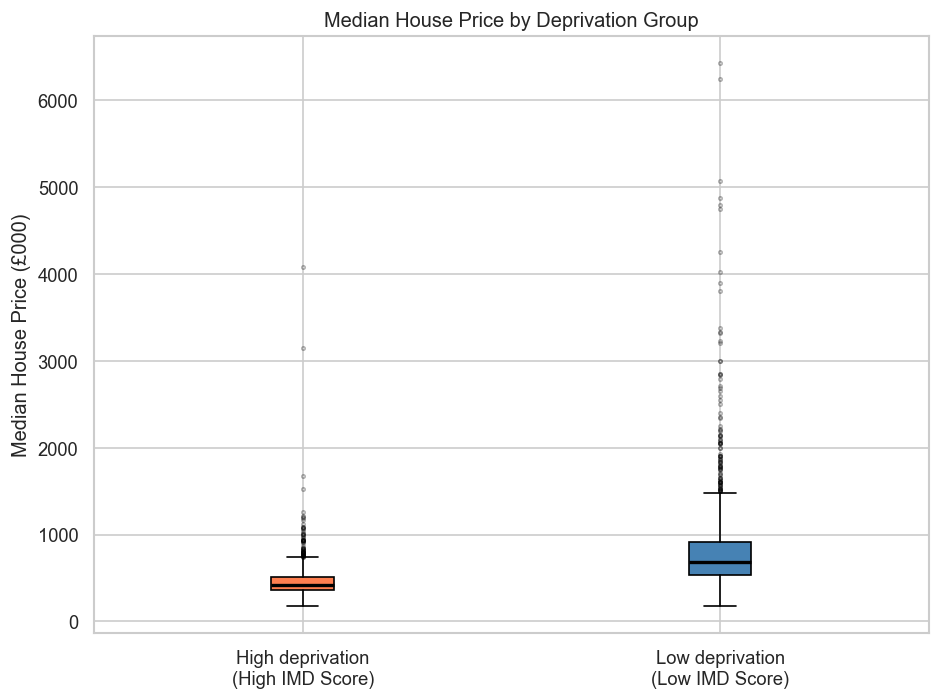

In [88]:
# Boxplots: distribution of house prices for Low vs High measures of deprivation
fig, ax = plt.subplots(figsize=(8, 6))

df = final_df

q75 = df['IMD Score'].quantile(0.75)
q25 = df['IMD Score'].quantile(0.25)

high_dep_prices = df[df['IMD Score'] >= q75]['Median House Price 2022'] / 1000
low_dep_prices = df[df['IMD Score'] <= q25]['Median House Price 2022'] / 1000

bp = ax.boxplot(
    [high_dep_prices, low_dep_prices],
    labels=[
        'High deprivation\n(High IMD Score)',
        'Low deprivation\n(Low IMD Score)'
    ],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')

ax.set_ylabel('Median House Price (£000)')
ax.set_title('Median House Price by Deprivation Group')

plt.tight_layout()
plt.show()

## Task 3: Correlation & Regression Analysis¶

### 1. Pearson Correlation Matrix: All Crime Categories vs House Price

Using the full dataset to compute pairwise Pearson correlations between each crime category and Median House Price.

=== Pearson r with Median House Price 2022 (All London) ===
  IMD Score                                  r = -0.3446  p = 9.6920e-133  ***
  Living Environment Deprivation Rank        r = -0.1425  p = 5.3711e-23  ***
  Crime Deprivation Rank                     r = +0.1377  p = 1.4249e-21  ***
  Housing and Services Deprivation Rank      r = +0.2857  p = 4.8748e-90  ***
  Health Deprivation Rank                    r = +0.3578  p = 1.1105e-143  ***
  Employment Deprivation Rank                r = +0.3874  p = 3.3590e-170  ***
  Income Deprivation Rank                    r = +0.4307  p = 3.4174e-214  ***
  Education Deprivation Rank                 r = +0.4501  p = 5.0880e-236  ***


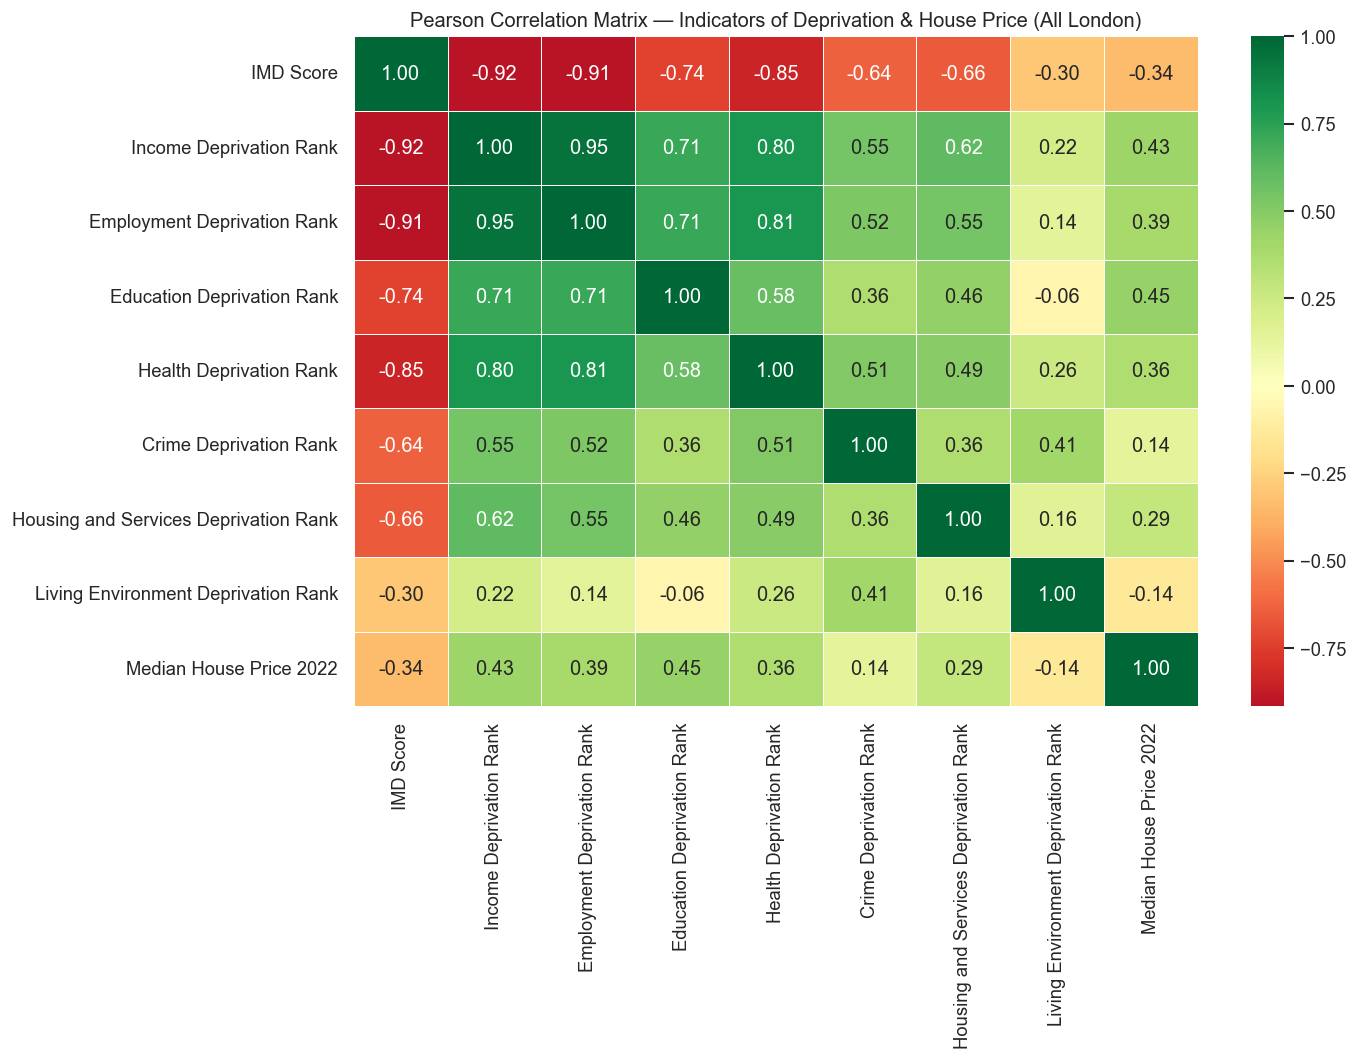

In [89]:
# Define the variable for the key analysis metrics used throughout Tasks 1–4

IMD_COLS = [
    'IMD Score', 'Income Deprivation Rank', 'Employment Deprivation Rank', 'Education Deprivation Rank', 'Health Deprivation Rank',
    'Crime Deprivation Rank', 'Housing and Services Deprivation Rank', 'Living Environment Deprivation Rank'
]

corr_cols = IMD_COLS + ['Median House Price 2022']
corr_matrix = final_df[corr_cols].corr()

# Print correlation with house price
print('=== Pearson r with Median House Price 2022 (All London) ===')
price_corr = corr_matrix['Median House Price 2022'].drop('Median House Price 2022').sort_values()
for var, r_val in price_corr.items():
    _, p_val = pearsonr(final_df[var], final_df['Median House Price 2022'])
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f'  {var:<42} r = {r_val:+.4f}  p = {p_val:.4e}  {sig}')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix — Indicators of Deprivation & House Price (All London)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Task 4: Analytical Insights and Recommendations

We summarise the key numerical findings across all LSOAs and translate them into actionable recommendations for homebuyers, investors, and local authorities.

In [90]:
print("=" * 65)
print("Summary Statistics")
print("=" * 65)

# Pearson correlation
r, _ = pearsonr(final_df['IMD Score'], final_df['Median House Price 2022'])

# Simple OLS regression
X = sm.add_constant(final_df['IMD Score'])
simple_model = sm.OLS(final_df['Median House Price 2022'], X).fit()

print(f"Number of LSOAs:               {len(final_df)}")
print(f"Pearson correlation (r):       {r:.4f}")
print(f"Simple OLS slope:              {simple_model.params['IMD Score']:.2f}")
print(f"Simple OLS R²:                 {simple_model.rsquared:.4f}")
print(f"H1 one-tailed p-value:         {p_one:.4e}")

Summary Statistics
Number of LSOAs:               4757
Pearson correlation (r):       -0.3446
Simple OLS slope:              -12786.22
Simple OLS R²:                 0.1188
H1 one-tailed p-value:         1.1283e-88


### Stakeholder Recommendations

#### Data-to-Insight Summary
| Scenario | r | 
| :--- | :---: |
| London LSOAs | -0.3446 | 

#### A. For Homebuyers
- Deprivation should be considered **alongside other factors** when purchasing property.
- More deprived neighbourhoods may offer **lower purchase prices** and **greater affordability**.
- Buyers should also evaluate schools, transport links, crime rates, healthcare access and future regeneration plans.
- Lower prices may reflect broader socioeconomic conditions rather than simply representing "good value."

#### B. For Investors

Potential opportunities:
- Lower acquisition costs in deprived areas.
- Potential capital appreciation where regeneration programmes are planned.
- Higher rental yields may be achievable because purchase prices are lower.

Potential risks:
- Slower capital growth.
- Greater market uncertainty.
- Higher tenant turnover or management costs in some locations.

#### C. For Local Authorities and Planners
The findings provide evidence that deprivation is associated with lower property values.

Policy implications include:
- Regeneration initiatives to tackle deprivation should be prioritised in highly deprived neighbourhoods.
- Services in transport, education and healthcare should be improved to increase neighbourhood attractiveness.
- Housing affordability **alongside** deprivation should be monitored to ensure that regeneration does not unintentionally displace existing residents through rapid increases in property values.
- **Be aware of outliers such as Westminster:** This borough should be treated as an outlier as its profile in terms of socio-economic factors and house pricing 